In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from google.colab import drive
from joblib import dump, load

def load_data_from_drive(file_path):
    """
    Load data and separate features and labels
    """
    try:
        drive.mount('/content/drive')

        if file_path.endswith('.xlsx'):
            df = pd.read_excel(file_path)
        elif file_path.endswith('.csv'):
            df = pd.read_csv(file_path)
        else:
            raise ValueError("File must be either .xlsx or .csv")

        # Remove unnamed columns
        df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

        # Define target columns
        target_columns = ['Fault', 'FaultL', 'FaultP']

        # Separate features and labels
        X = df.drop(columns=target_columns)
        y = df[target_columns]

        print("\nFeature columns:", list(X.columns))
        print("Number of features:", len(X.columns))
        print("\nLabel columns:", list(y.columns))

        return X, y

    except Exception as e:
        print(f"Error loading data: {str(e)}")
        return None, None

class FaultDetectionModel:
    def __init__(self, X, y):
        self.X = X
        self.y = y
        self.scaler = StandardScaler()
        self.label_encoders = {}
        self.valid_targets = []

        # Scale features
        self.X_scaled = self.scaler.fit_transform(self.X)

        # Save feature names for future reference
        dump(list(X.columns), '/content/drive/MyDrive/feature_names.joblib')

        # Encode and validate targets
        self.y_encoded = pd.DataFrame()
        for column in self.y.columns:
            unique_values = self.y[column].unique()
            print(f"\nUnique values in {column}:", unique_values)

            if len(unique_values) >= 2:
                self.label_encoders[column] = LabelEncoder()
                self.y_encoded[column] = self.label_encoders[column].fit_transform(self.y[column])
                self.valid_targets.append(column)
            else:
                print(f"Warning: {column} has only one class ({unique_values[0]}). Skipping this target.")

        if not self.valid_targets:
            raise ValueError("No valid target variables found with at least 2 classes.")

        print(f"\nValid targets for modeling: {self.valid_targets}")

        # Initialize models for each target
        self.models = {target: {
            'lr': LogisticRegression(max_iter=1000),
            'rf': RandomForestClassifier(),
            'nn': MLPClassifier(max_iter=1000)
        } for target in self.valid_targets}

    def train_models(self):
        """Train separate models for each target"""
        print("\nTraining models...")

        for target in self.valid_targets:
            print(f"\nTraining models for {target}...")
            y_target = self.y_encoded[target]

            # Train models for this target
            self.models[target]['lr'].fit(self.X_scaled, y_target)
            self.models[target]['rf'].fit(self.X_scaled, y_target)
            self.models[target]['nn'].fit(self.X_scaled, y_target)

            # Save models for this target
            dump(self.models[target]['lr'], f'/content/drive/MyDrive/lr_model_{target}.joblib')
            dump(self.models[target]['rf'], f'/content/drive/MyDrive/rf_model_{target}.joblib')
            dump(self.models[target]['nn'], f'/content/drive/MyDrive/nn_model_{target}.joblib')

            # Save label encoder for this target
            dump(self.label_encoders[target], f'/content/drive/MyDrive/label_encoder_{target}.joblib')

        # Save scaler
        dump(self.scaler, '/content/drive/MyDrive/scaler.joblib')
        print("\nAll models and preprocessing objects saved to Google Drive.")

    def evaluate_models(self):
        """Evaluate models for each target"""
        for target in self.valid_targets:
            print(f"\nEvaluating models for {target}...")
            y_target = self.y_encoded[target]

            for model_name, model in self.models[target].items():
                y_pred = model.predict(self.X_scaled)

                # Calculate metrics
                accuracy = accuracy_score(y_target, y_pred)
                f1 = f1_score(y_target, y_pred, average='macro')
                conf_matrix = confusion_matrix(y_target, y_pred)

                print(f"\n{model_name.upper()} Model:")
                print(f"Accuracy: {accuracy:.2f}")
                print(f"F1 Score: {f1:.2f}")
                print("Confusion Matrix:")
                print(conf_matrix)

                # Plot confusion matrix
                self.plot_confusion_matrix(conf_matrix, target, model_name)

    def plot_confusion_matrix(self, cm, target, model_name):
        plt.figure(figsize=(8, 6))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title(f'Confusion Matrix - {target} - {model_name}')
        plt.colorbar()

        classes = self.label_encoders[target].classes_
        tick_marks = np.arange(len(classes))
        plt.xticks(tick_marks, classes)
        plt.yticks(tick_marks, classes)

        # Add text annotations
        thresh = cm.max() / 2.
        for i, j in np.ndindex(cm.shape):
            plt.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")

        plt.ylabel('True label')
        plt.xlabel('Predicted label')
        plt.tight_layout()
        plt.show()

# Example usage
if __name__ == "__main__":
    file_path = '/content/drive/MyDrive/Book1.xlsx'  # Update with your dataset path
    X, y = load_data_from_drive(file_path)

    if X is not None and y is not None:
        model = FaultDetectionModel(X, y)
        model.train_models()
        model.evaluate_models()
    else:
        print("Data loading failed.")

Error loading data: Error: credential propagation was unsuccessful
Data loading failed.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Feature columns: ['Va', 'Vb', 'Vc', 'THD_Va', 'THD_Vb', 'THD_Vc', 'Ia', 'Ib', 'Ic', 'THD_Ia', 'THD_Ib', 'THD_Ic', 'Pa', 'Pb', 'Pc', 'Displacement', 'Velocity', 'Acceleration', 'Hot Spot']
Number of features: 19

Label columns: ['Fault', 'FaultL', 'FaultP', 'LoopI']

Unique values in Fault: [0 1]

Unique values in FaultL: [0 1 2 3 4]

Unique values in FaultP: [0 2]

Classification targets: ['Fault', 'FaultL', 'FaultP']
Regression targets: ['LoopI']

Training models...

Training classification models for Fault...

Training classification models for FaultL...

Training classification models for FaultP...

Training regression models for LoopI...

All models and preprocessing objects saved to Google Drive.

Evaluating classification models for Fault...

LR Model:
Accuracy: 1.00
F1 Score: 1.00
Confusion Matrix:
[[2000    0]
 [   0 8000]]


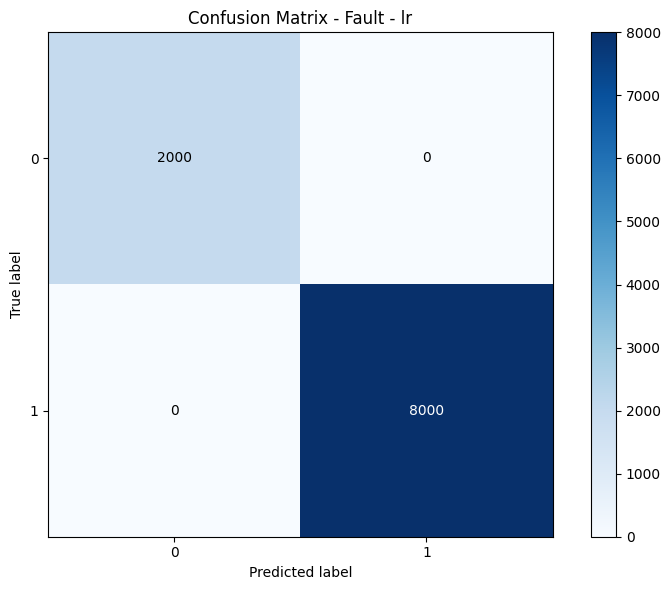


RF Model:
Accuracy: 1.00
F1 Score: 1.00
Confusion Matrix:
[[2000    0]
 [   0 8000]]


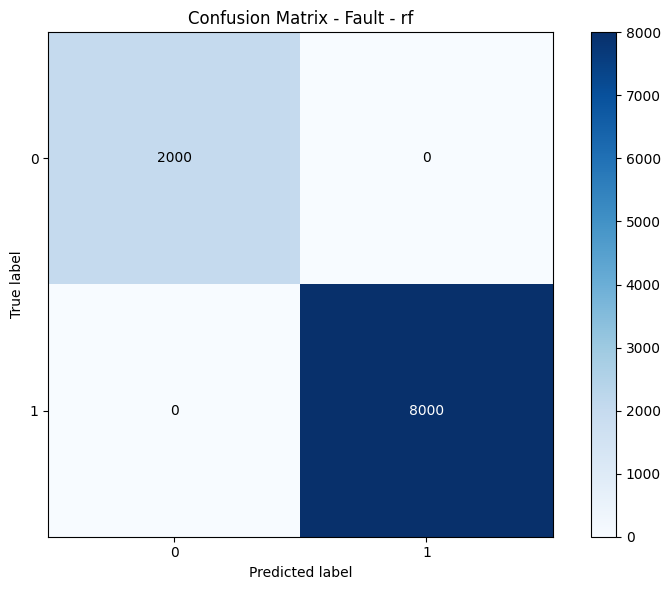


NN Model:
Accuracy: 1.00
F1 Score: 1.00
Confusion Matrix:
[[2000    0]
 [   0 8000]]


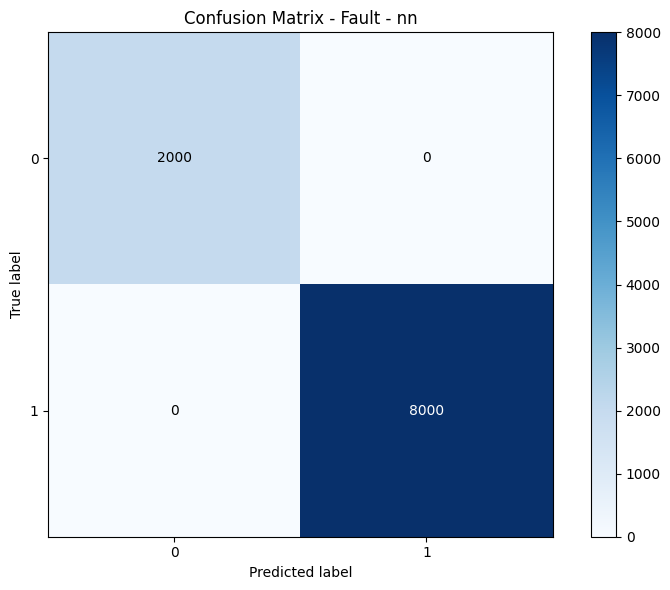


Evaluating classification models for FaultL...

LR Model:
Accuracy: 1.00
F1 Score: 1.00
Confusion Matrix:
[[2000    0    0    0    0]
 [   0 2000    0    0    0]
 [   0    0 2000    0    0]
 [   0    0    0 2000    0]
 [   0    0    0    0 2000]]


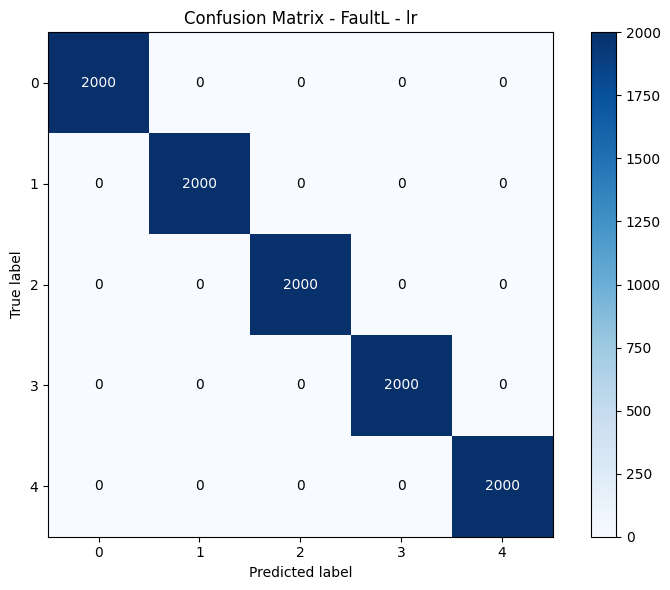


RF Model:
Accuracy: 1.00
F1 Score: 1.00
Confusion Matrix:
[[2000    0    0    0    0]
 [   0 2000    0    0    0]
 [   0    0 2000    0    0]
 [   0    0    0 2000    0]
 [   0    0    0    0 2000]]


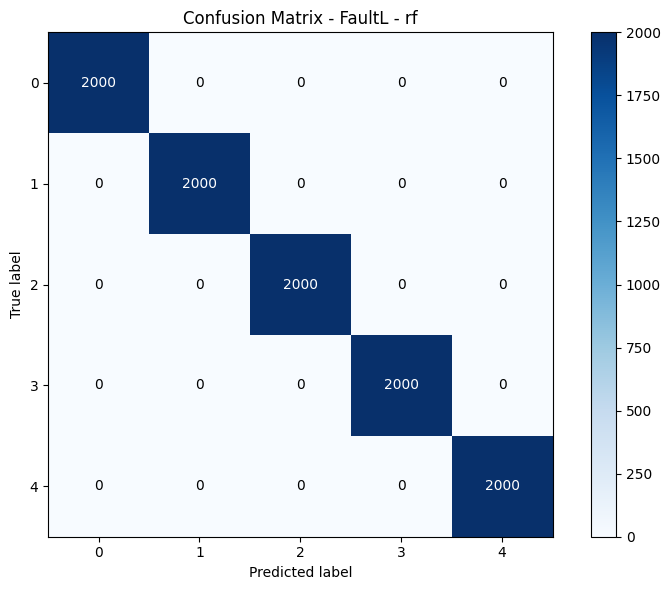


NN Model:
Accuracy: 1.00
F1 Score: 1.00
Confusion Matrix:
[[2000    0    0    0    0]
 [   0 2000    0    0    0]
 [   0    0 2000    0    0]
 [   0    0    0 2000    0]
 [   0    0    0    0 2000]]


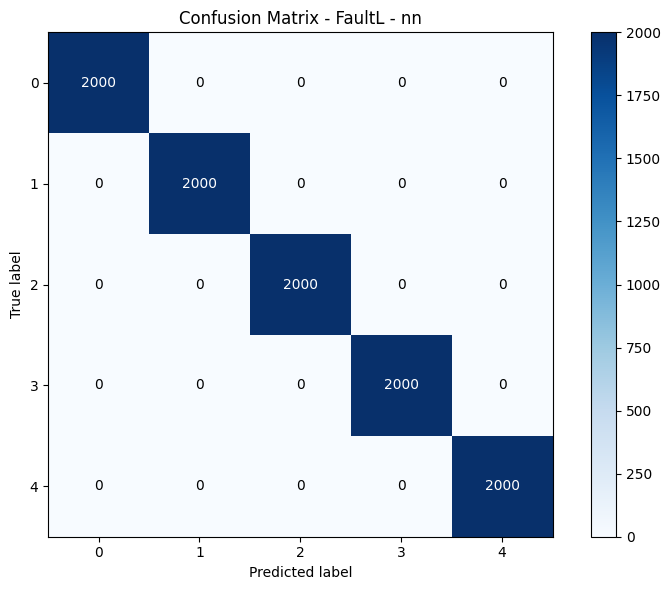


Evaluating classification models for FaultP...

LR Model:
Accuracy: 1.00
F1 Score: 1.00
Confusion Matrix:
[[2000    0]
 [   0 8000]]


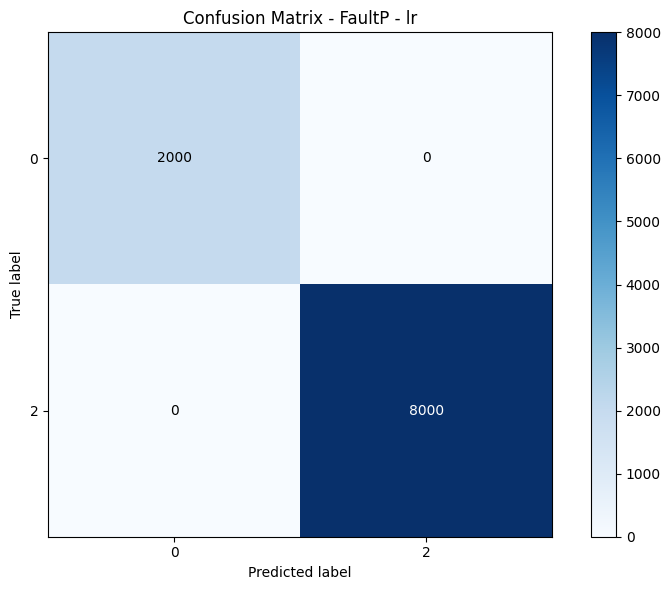


RF Model:
Accuracy: 1.00
F1 Score: 1.00
Confusion Matrix:
[[2000    0]
 [   0 8000]]


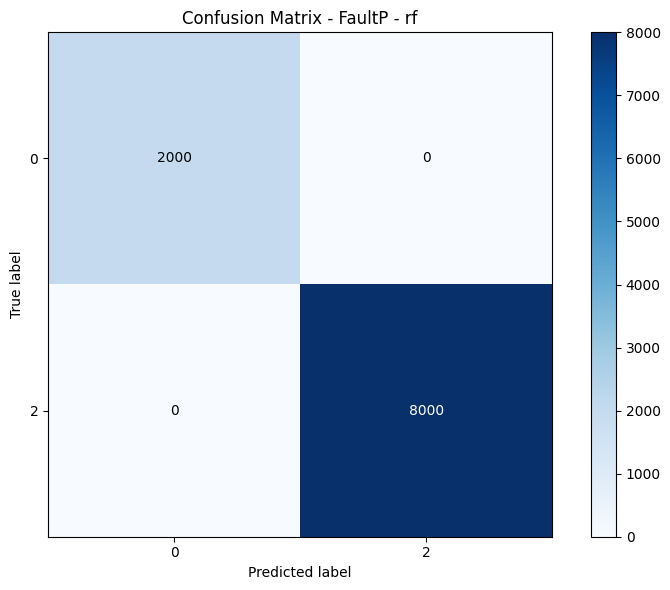


NN Model:
Accuracy: 1.00
F1 Score: 1.00
Confusion Matrix:
[[2000    0]
 [   0 8000]]


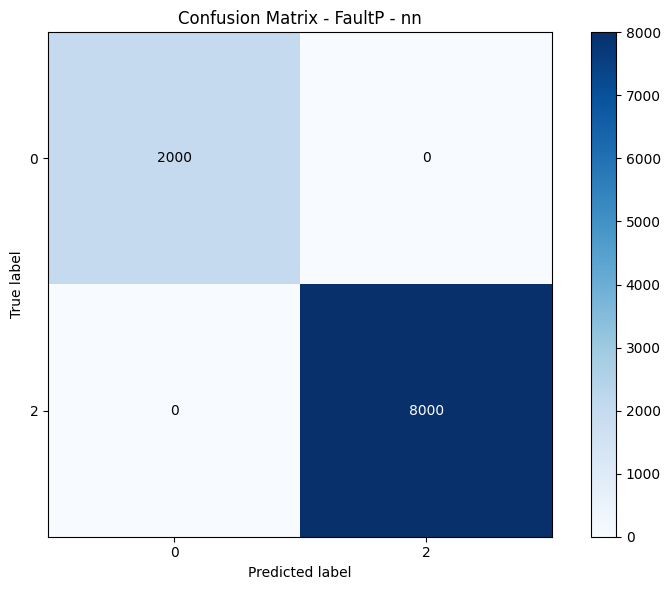


Evaluating regression models for LoopI...

LR Model:
Mean Squared Error: 0.00
R-squared: 1.00


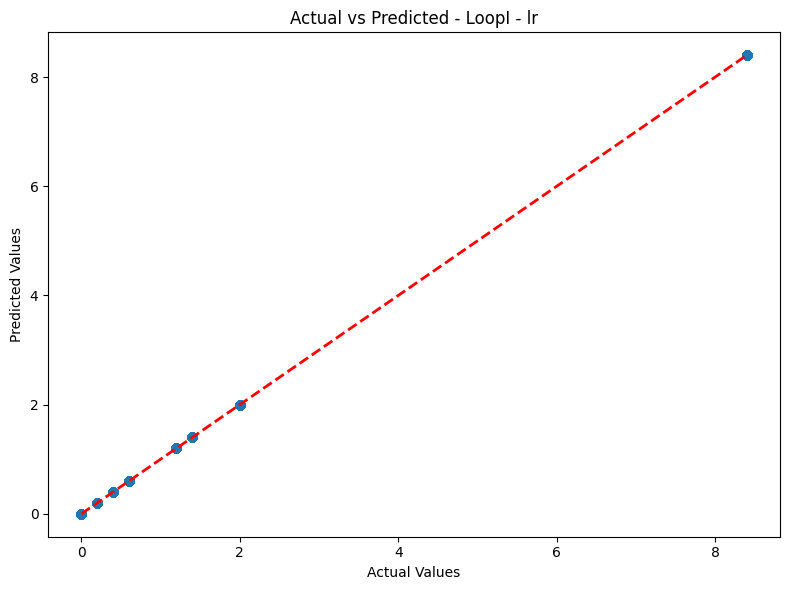


RF Model:
Mean Squared Error: 0.00
R-squared: 1.00


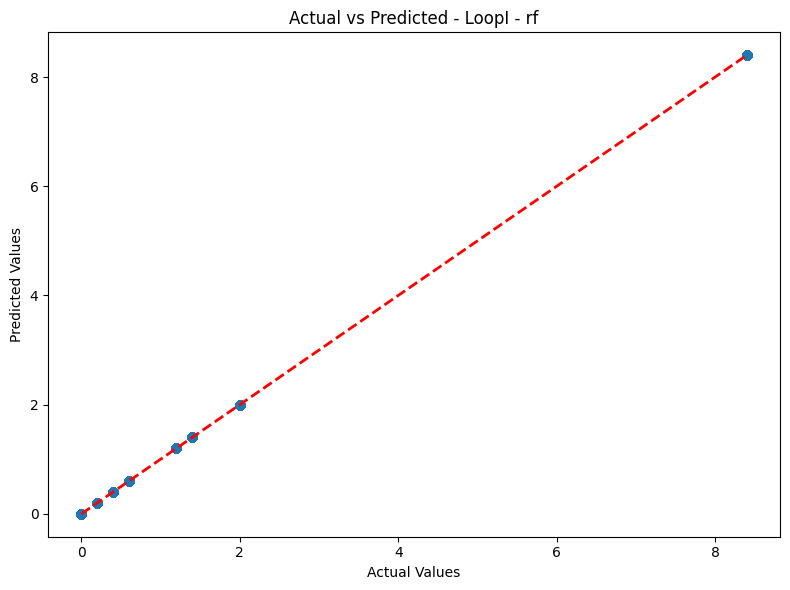


NN Model:
Mean Squared Error: 0.00
R-squared: 1.00


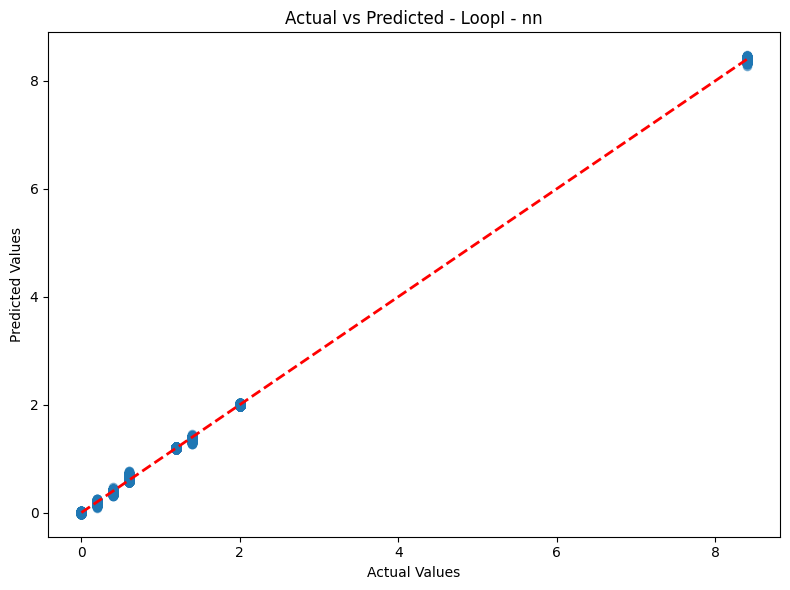

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neural_network import MLPClassifier, MLPRegressor
from google.colab import drive
from joblib import dump, load

def load_data_from_drive(file_path):
    """
    Load data and separate features and labels
    """
    try:
        drive.mount('/content/drive')

        if file_path.endswith('.xlsx'):
            df = pd.read_excel(file_path)
        elif file_path.endswith('.csv'):
            df = pd.read_csv(file_path)
        else:
            raise ValueError("File must be either .xlsx or .csv")

        # Remove unnamed columns
        df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

        # Define target columns
        target_columns = ['Fault', 'FaultL', 'FaultP', 'LoopI']

        # Separate features and labels
        X = df.drop(columns=target_columns)
        y = df[target_columns]

        print("\nFeature columns:", list(X.columns))
        print("Number of features:", len(X.columns))
        print("\nLabel columns:", list(y.columns))

        return X, y

    except Exception as e:
        print(f"Error loading data: {str(e)}")
        return None, None

class FaultDetectionModel:
    def __init__(self, X, y):
        self.X = X
        self.y = y
        self.scaler = StandardScaler()
        self.label_encoders = {}
        self.classification_targets = []
        self.regression_targets = []

        # Scale features
        self.X_scaled = self.scaler.fit_transform(self.X)

        # Save feature names for future reference
        dump(list(X.columns), '/content/drive/MyDrive/feature_names.joblib')

        # Identify and process targets
        self.y_encoded = pd.DataFrame()
        for column in self.y.columns:
            if column == 'LoopI':
                self.y_encoded[column] = self.y[column]
                self.regression_targets.append(column)
            else:
                unique_values = self.y[column].unique()
                print(f"\nUnique values in {column}:", unique_values)

                if len(unique_values) >= 2:
                    self.label_encoders[column] = LabelEncoder()
                    self.y_encoded[column] = self.label_encoders[column].fit_transform(self.y[column])
                    self.classification_targets.append(column)
                else:
                    print(f"Warning: {column} has only one class ({unique_values[0]}). Skipping this target.")

        print(f"\nClassification targets: {self.classification_targets}")
        print(f"Regression targets: {self.regression_targets}")

        # Initialize classification models
        self.classification_models = {target: {
            'lr': LogisticRegression(max_iter=1000),
            'rf': RandomForestClassifier(),
            'nn': MLPClassifier(max_iter=1000)
        } for target in self.classification_targets}

        # Initialize regression models
        self.regression_models = {target: {
            'lr': LinearRegression(),
            'rf': RandomForestRegressor(),
            'nn': MLPRegressor(max_iter=1000)
        } for target in self.regression_targets}

    def train_models(self):
        """Train separate models for classification and regression targets"""
        print("\nTraining models...")

        # Train classification models
        for target in self.classification_targets:
            print(f"\nTraining classification models for {target}...")
            y_target = self.y_encoded[target]

            for model_name, model in self.classification_models[target].items():
                model.fit(self.X_scaled, y_target)
                dump(model, f'/content/drive/MyDrive/classification_{model_name}_model_{target}.joblib')

            # Save label encoder
            dump(self.label_encoders[target], f'/content/drive/MyDrive/label_encoder_{target}.joblib')

        # Train regression models
        for target in self.regression_targets:
            print(f"\nTraining regression models for {target}...")
            y_target = self.y_encoded[target]

            for model_name, model in self.regression_models[target].items():
                model.fit(self.X_scaled, y_target)
                dump(model, f'/content/drive/MyDrive/regression_{model_name}_model_{target}.joblib')

        # Save scaler
        dump(self.scaler, '/content/drive/MyDrive/scaler.joblib')
        print("\nAll models and preprocessing objects saved to Google Drive.")

    def evaluate_models(self):
        """Evaluate classification and regression models separately"""
        # Evaluate classification models
        for target in self.classification_targets:
            print(f"\nEvaluating classification models for {target}...")
            y_target = self.y_encoded[target]

            for model_name, model in self.classification_models[target].items():
                y_pred = model.predict(self.X_scaled)
                accuracy = accuracy_score(y_target, y_pred)
                f1 = f1_score(y_target, y_pred, average='macro')
                conf_matrix = confusion_matrix(y_target, y_pred)

                print(f"\n{model_name.upper()} Model:")
                print(f"Accuracy: {accuracy:.2f}")
                print(f"F1 Score: {f1:.2f}")
                print("Confusion Matrix:")
                print(conf_matrix)

                self.plot_confusion_matrix(conf_matrix, target, model_name)

        # Evaluate regression models
        for target in self.regression_targets:
            print(f"\nEvaluating regression models for {target}...")
            y_target = self.y_encoded[target]

            for model_name, model in self.regression_models[target].items():
                y_pred = model.predict(self.X_scaled)
                mse = mean_squared_error(y_target, y_pred)
                r2 = r2_score(y_target, y_pred)

                print(f"\n{model_name.upper()} Model:")
                print(f"Mean Squared Error: {mse:.2f}")
                print(f"R-squared: {r2:.2f}")

                # Plot actual vs predicted values
                self.plot_regression_results(y_target, y_pred, target, model_name)

    def plot_confusion_matrix(self, cm, target, model_name):
        plt.figure(figsize=(8, 6))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title(f'Confusion Matrix - {target} - {model_name}')
        plt.colorbar()

        classes = self.label_encoders[target].classes_
        tick_marks = np.arange(len(classes))
        plt.xticks(tick_marks, classes)
        plt.yticks(tick_marks, classes)

        # Add text annotations
        thresh = cm.max() / 2.
        for i, j in np.ndindex(cm.shape):
            plt.text(j, i, format(cm[i, j], 'd'),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")

        plt.ylabel('True label')
        plt.xlabel('Predicted label')
        plt.tight_layout()
        plt.show()

    def plot_regression_results(self, y_true, y_pred, target, model_name):
        plt.figure(figsize=(8, 6))
        plt.scatter(y_true, y_pred, alpha=0.5)
        plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
        plt.xlabel('Actual Values')
        plt.ylabel('Predicted Values')
        plt.title(f'Actual vs Predicted - {target} - {model_name}')
        plt.tight_layout()
        plt.show()

# Example usage
if __name__ == "__main__":
    file_path = '/content/drive/MyDrive/Book2.xlsx'  # Update with your dataset path
    X, y = load_data_from_drive(file_path)

    if X is not None and y is not None:
        model = FaultDetectionModel(X, y)
        model.train_models()
        model.evaluate_models()
    else:
        print("Data loading failed.")

Mounted at /content/drive

Feature columns: ['Ia', 'Ib', 'Ic', 'THD_Ia', 'THD_Ib', 'THD_Ic', 'Displacement', 'Velocity', 'Acceleration', 'Hot Spot']
Number of features: 10

Label columns: ['Fault', 'FaultL', 'FaultP', 'LoopI']

Unique values in Fault: [0 1]

Unique values in FaultL: [0 1 2 3 4]

Unique values in FaultP: [0 1 3]

Analyzing relationships with LoopI...


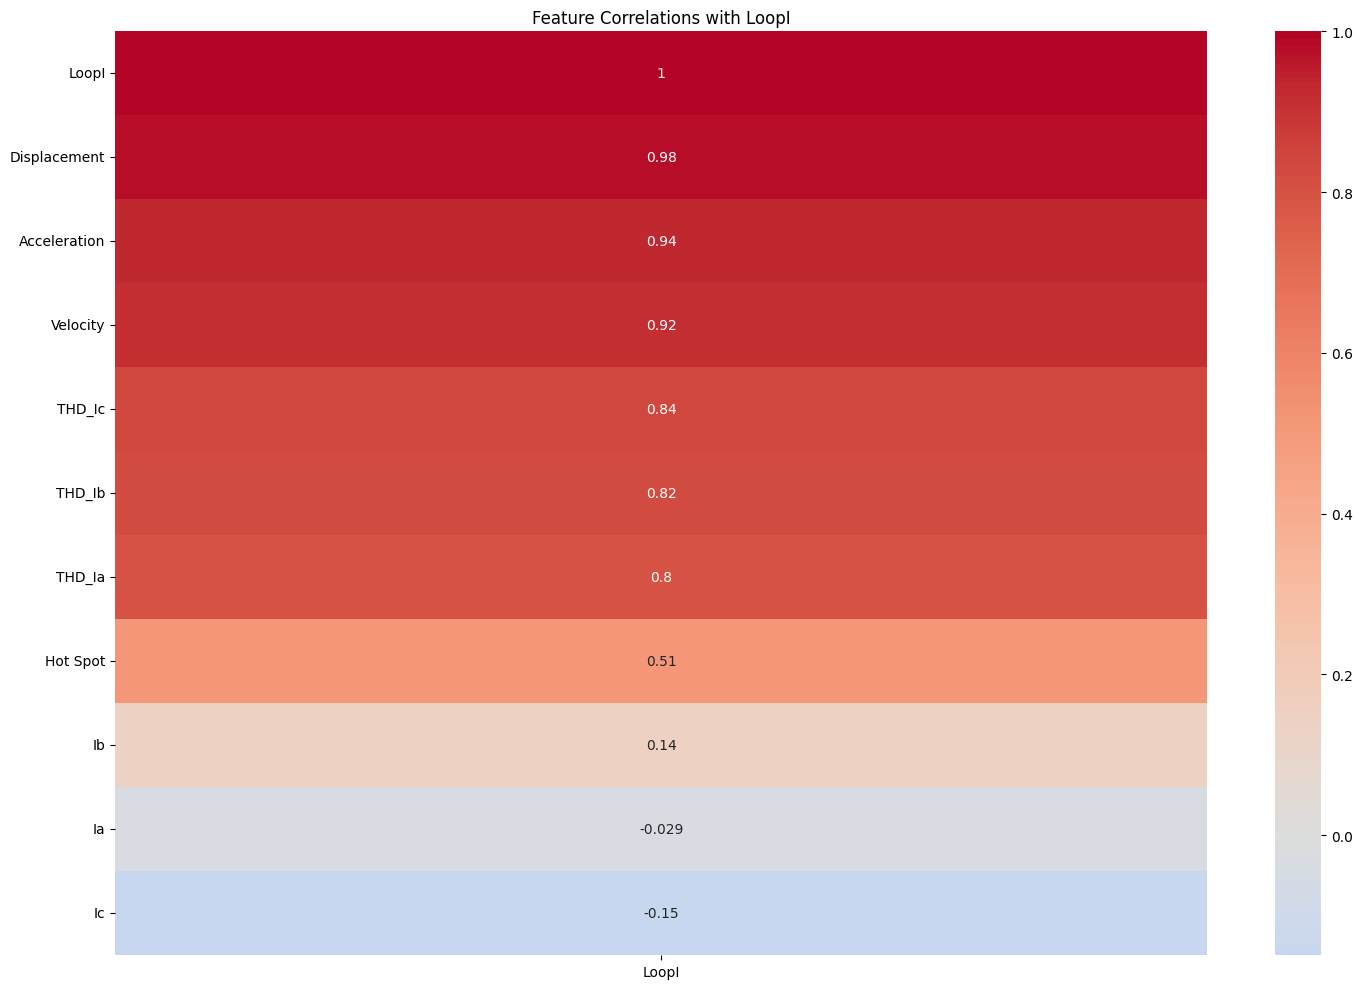

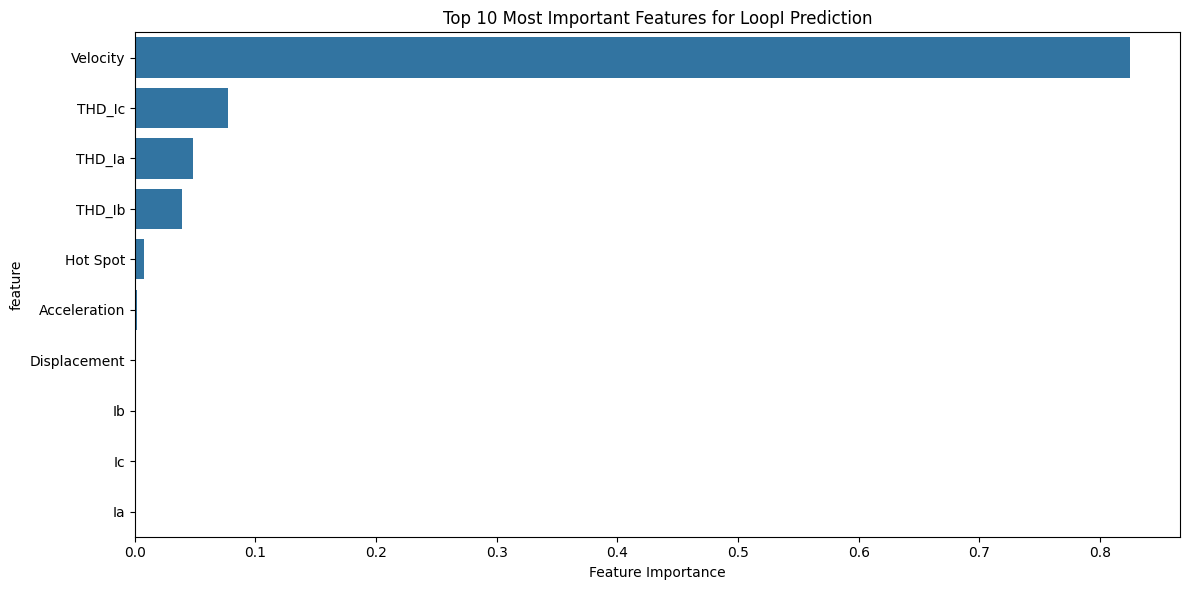

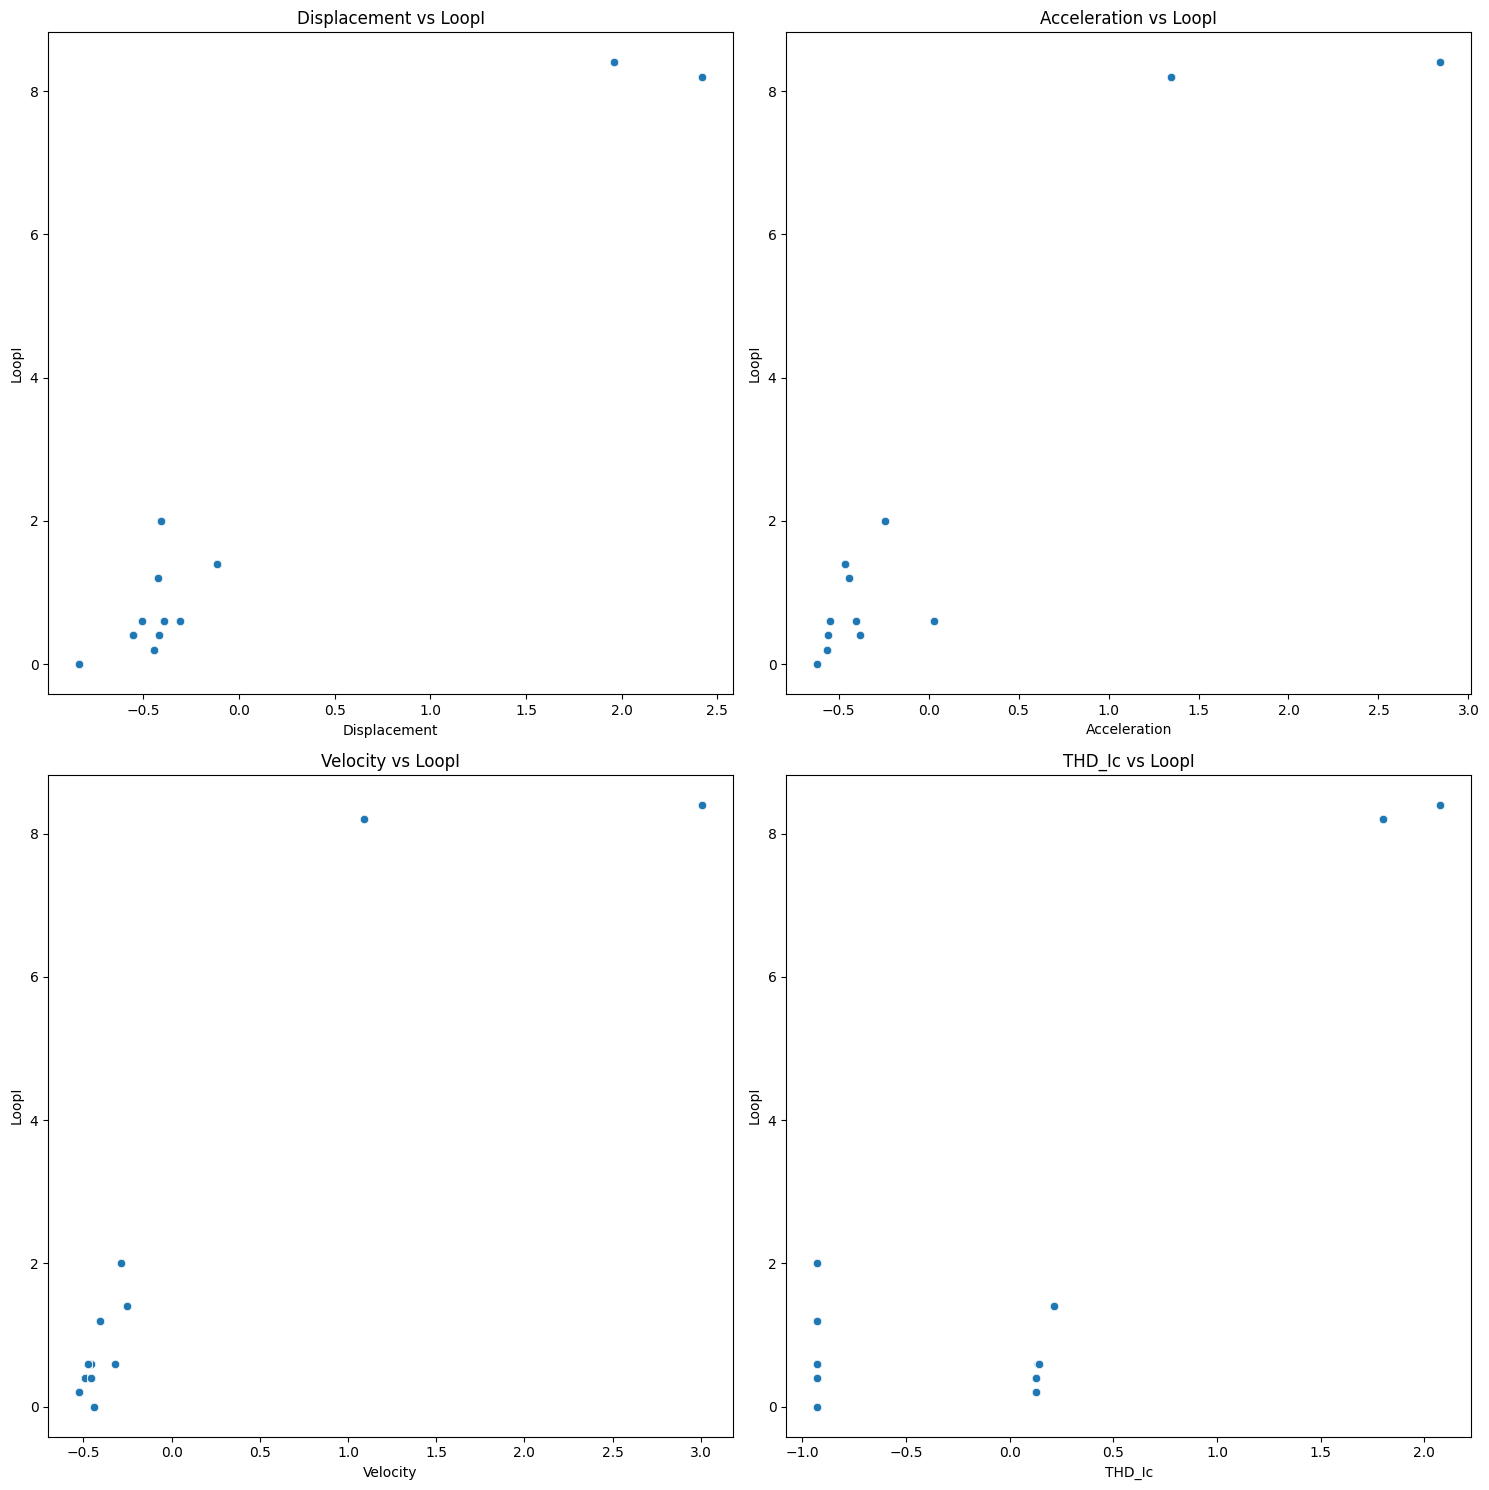


Top 5 Feature Correlations with LoopI:
LoopI           1.000000
Displacement    0.981219
Acceleration    0.937123
Velocity        0.917479
THD_Ic          0.841284
Name: LoopI, dtype: float64

Training models...

Training classification models for Fault...

Training classification models for FaultL...

Training classification models for FaultP...

Training regression models for LoopI...

All models and preprocessing objects saved to Google Drive.

Evaluating classification models for Fault...

LR Model:
Accuracy: 1.00
F1 Score: 1.00
Confusion Matrix:
[[1986    0]
 [   0 9882]]


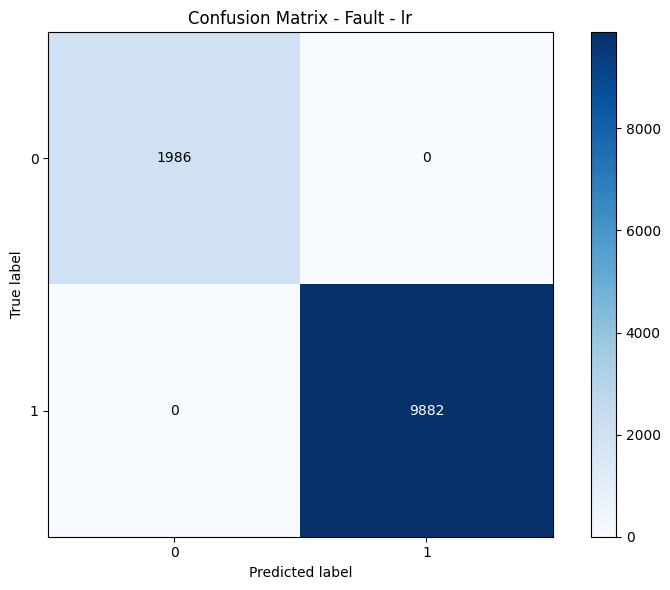


RF Model:
Accuracy: 1.00
F1 Score: 1.00
Confusion Matrix:
[[1986    0]
 [   0 9882]]


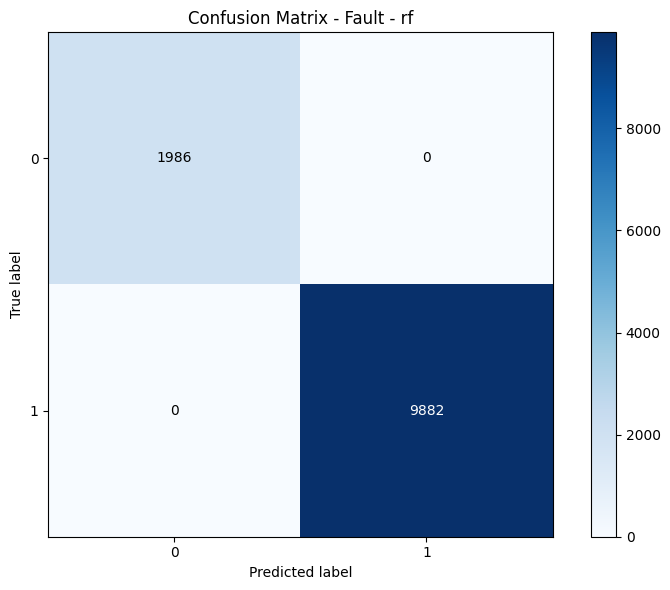


NN Model:
Accuracy: 1.00
F1 Score: 1.00
Confusion Matrix:
[[1986    0]
 [   0 9882]]


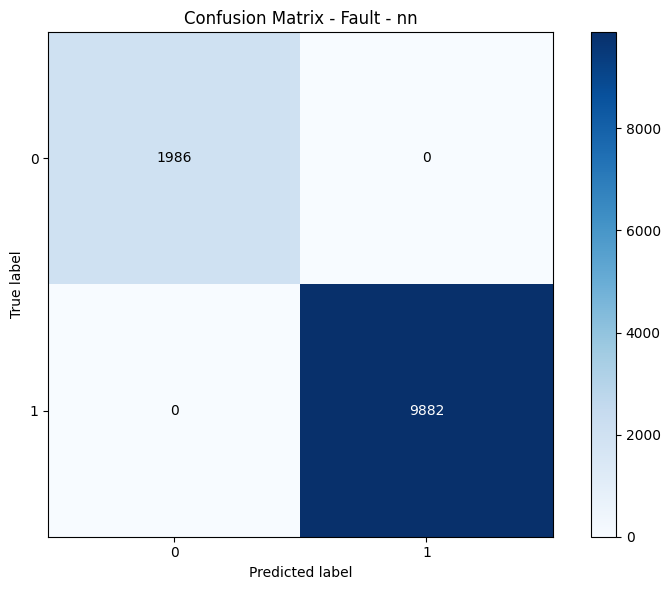


Evaluating classification models for FaultL...

LR Model:
Accuracy: 1.00
F1 Score: 1.00
Confusion Matrix:
[[1986    0    0    0    0]
 [   0 1976    0    0    0]
 [   0    0 2955    0    0]
 [   0    0    0 1974    0]
 [   0    0    0    0 2977]]


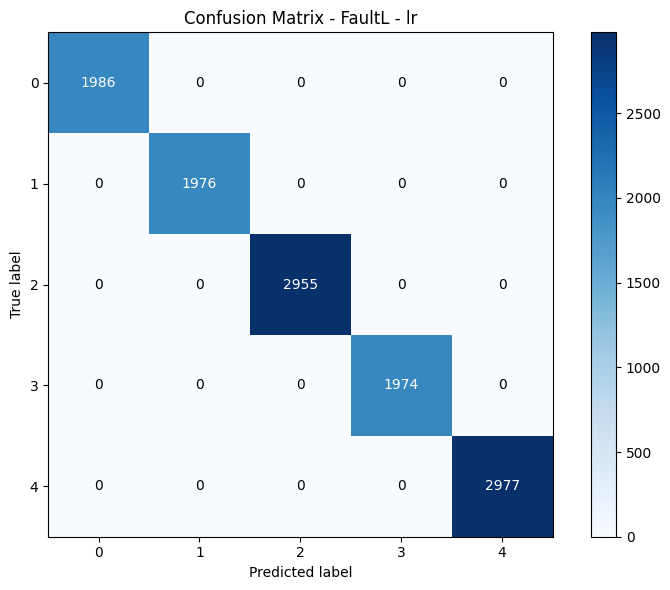


RF Model:
Accuracy: 1.00
F1 Score: 1.00
Confusion Matrix:
[[1986    0    0    0    0]
 [   0 1976    0    0    0]
 [   0    0 2955    0    0]
 [   0    0    0 1974    0]
 [   0    0    0    0 2977]]


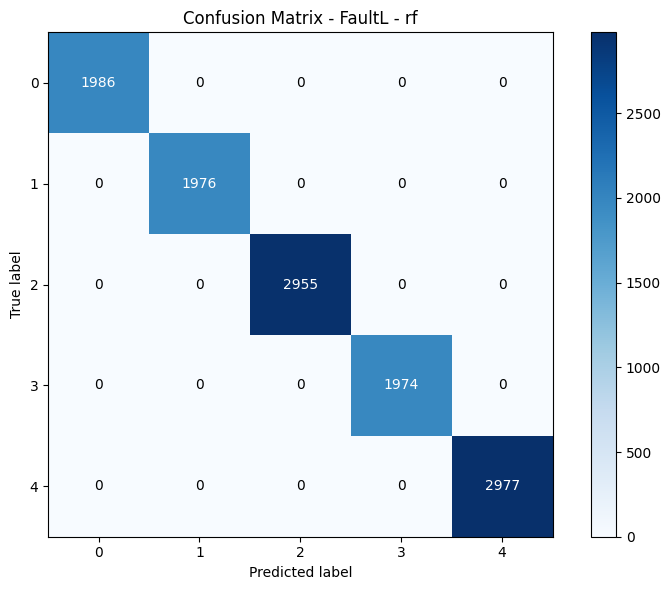


NN Model:
Accuracy: 1.00
F1 Score: 1.00
Confusion Matrix:
[[1986    0    0    0    0]
 [   0 1976    0    0    0]
 [   0    0 2955    0    0]
 [   0    0    0 1974    0]
 [   0    0    0    0 2977]]


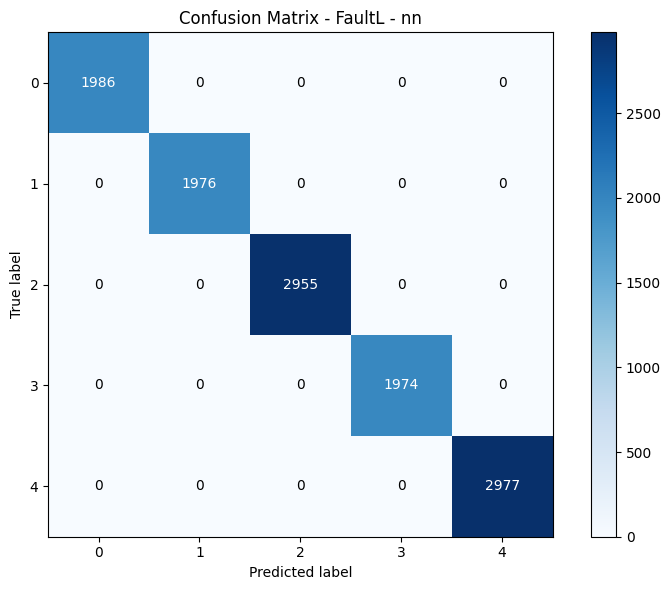


Evaluating classification models for FaultP...

LR Model:
Accuracy: 1.00
F1 Score: 1.00
Confusion Matrix:
[[1986    0    0]
 [   0 7905    0]
 [   0    0 1977]]


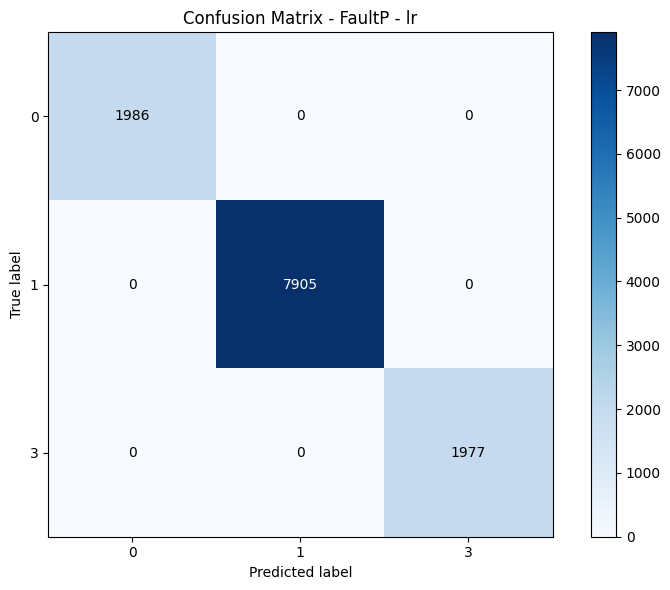


RF Model:
Accuracy: 1.00
F1 Score: 1.00
Confusion Matrix:
[[1986    0    0]
 [   0 7905    0]
 [   0    0 1977]]


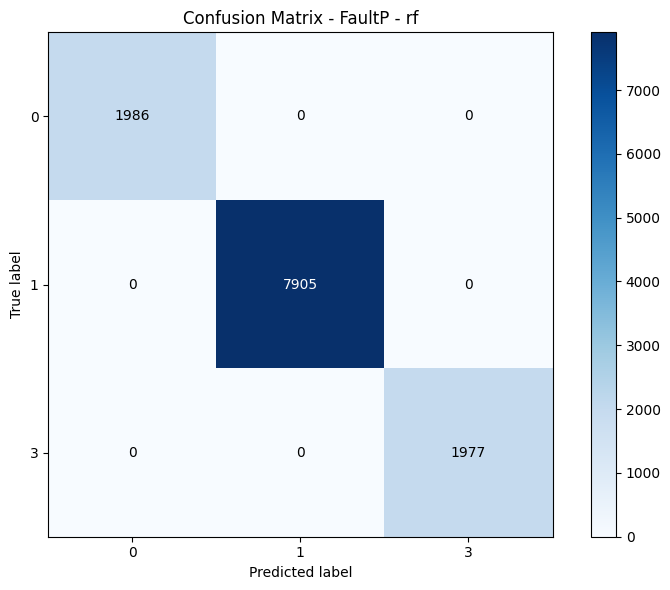


NN Model:
Accuracy: 1.00
F1 Score: 1.00
Confusion Matrix:
[[1986    0    0]
 [   0 7905    0]
 [   0    0 1977]]


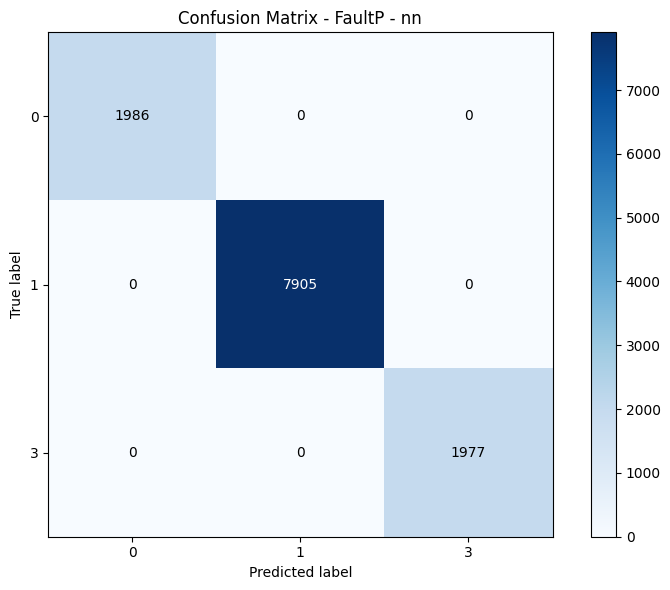


Evaluating regression models for LoopI...

LR Model:
Mean Squared Error: 0.02
R-squared: 1.00


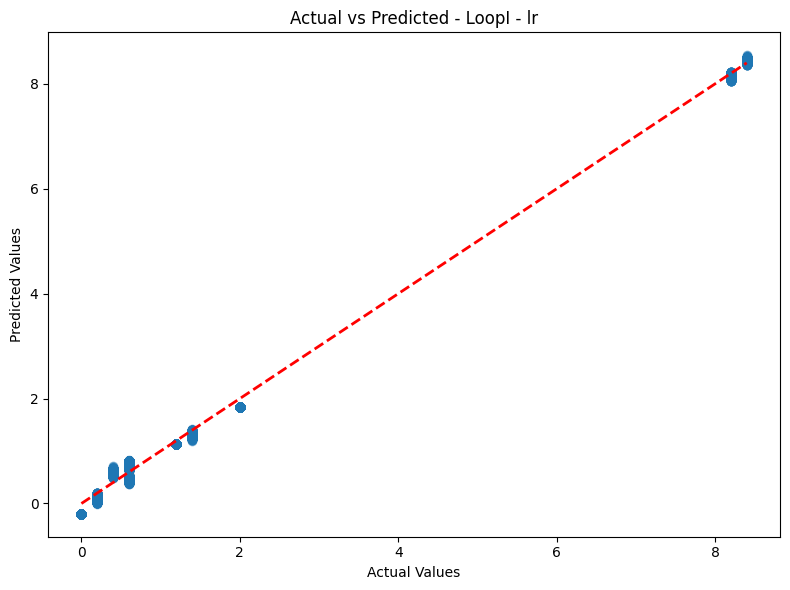


RF Model:
Mean Squared Error: 0.00
R-squared: 1.00


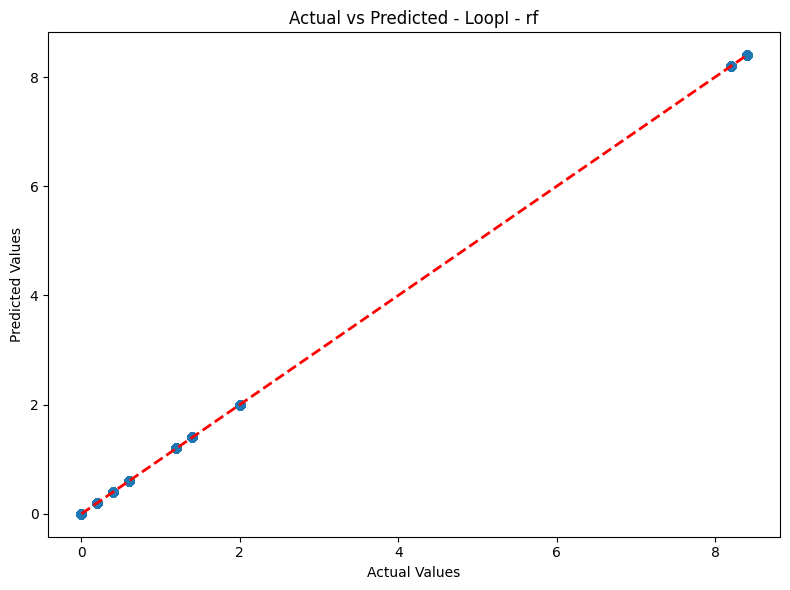


NN Model:
Mean Squared Error: 0.00
R-squared: 1.00


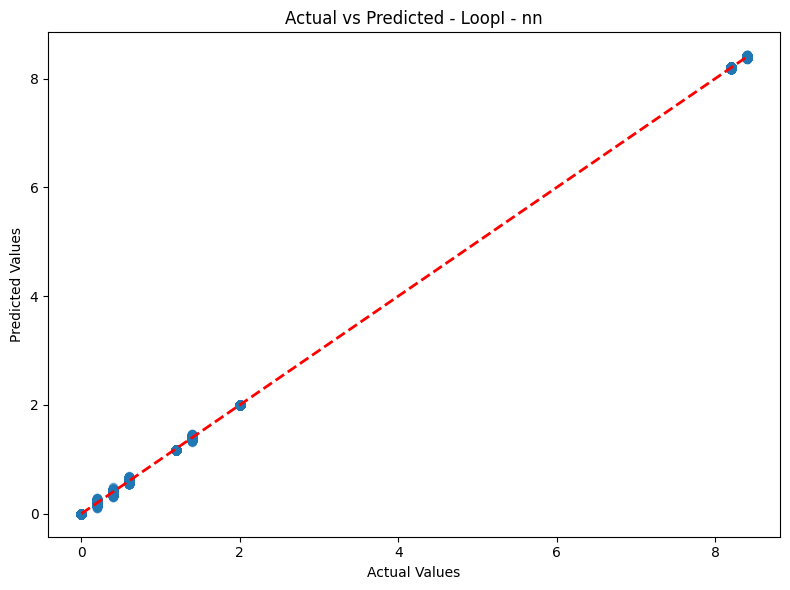

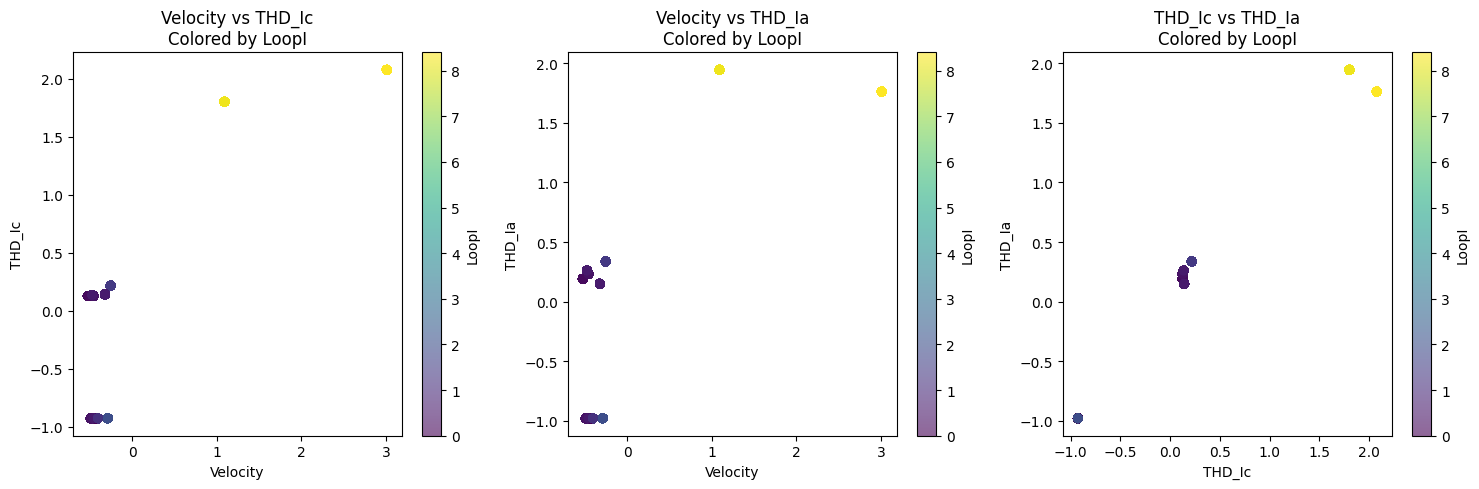

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neural_network import MLPClassifier, MLPRegressor
from google.colab import drive
from joblib import dump, load

def load_data_from_drive(file_path):
    """
    Load data and separate features and labels
    """
    try:
        drive.mount('/content/drive')

        if file_path.endswith('.xlsx'):
            df = pd.read_excel(file_path)
        elif file_path.endswith('.csv'):
            df = pd.read_csv(file_path)
        else:
            raise ValueError("File must be either .xlsx or .csv")

        # Remove unnamed columns
        df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

        # Define target columns
        target_columns = ['Fault', 'FaultL', 'FaultP', 'LoopI']

        # Separate features and labels
        X = df.drop(columns=target_columns)
        y = df[target_columns]

        print("\nFeature columns:", list(X.columns))
        print("Number of features:", len(X.columns))
        print("\nLabel columns:", list(y.columns))

        return X, y

    except Exception as e:
        print(f"Error loading data: {str(e)}")
        return None, None


class FaultDetectionModel:
    def __init__(self, X, y):
        self.X = X
        self.y = y
        self.scaler = StandardScaler()
        self.label_encoders = {}
        self.classification_targets = []
        self.regression_targets = []
        self.feature_names = list(X.columns)

        # Scale features
        self.X_scaled = self.scaler.fit_transform(self.X)

        # Save feature names for future reference
        dump(self.feature_names, '/content/drive/MyDrive/feature_names.joblib')

        # Process targets
        self.y_encoded = pd.DataFrame()
        for column in self.y.columns:
            if column == 'LoopI':
                self.y_encoded[column] = self.y[column]
                self.regression_targets.append(column)
            else:
                unique_values = self.y[column].unique()
                print(f"\nUnique values in {column}:", unique_values)

                if len(unique_values) >= 2:
                    self.label_encoders[column] = LabelEncoder()
                    self.y_encoded[column] = self.label_encoders[column].fit_transform(self.y[column])
                    self.classification_targets.append(column)
                else:
                    print(f"Warning: {column} has only one class ({unique_values[0]}). Skipping this target.")

        # Initialize models
        self.classification_models = {
            target: {
                'lr': LogisticRegression(max_iter=1000),
                'rf': RandomForestClassifier(),
                'nn': MLPClassifier(max_iter=1000)
            } for target in self.classification_targets
        }

        self.regression_models = {
            target: {
                'lr': LinearRegression(),
                'rf': RandomForestRegressor(),
                'nn': MLPRegressor(max_iter=1000)
            } for target in self.regression_targets
        }

        # Analyze feature relationships for LoopI
        if 'LoopI' in self.y.columns:
            self.analyze_loopi_relationships()

    def analyze_loopi_relationships(self):
        """Analyze and visualize relationships between features and LoopI"""
        print("\nAnalyzing relationships with LoopI...")

        # Create DataFrame with features and LoopI
        analysis_df = pd.DataFrame(self.X_scaled, columns=self.feature_names)
        analysis_df['LoopI'] = self.y['LoopI']

        # 1. Calculate and plot correlation matrix
        plt.figure(figsize=(15, 10))
        correlation_matrix = analysis_df.corr()
        sns.heatmap(
            correlation_matrix[['LoopI']].sort_values(by='LoopI', ascending=False),
            annot=True,
            cmap='coolwarm',
            center=0
        )
        plt.title('Feature Correlations with LoopI')
        plt.tight_layout()
        plt.show()

        # 2. Train Random Forest for feature importance
        rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
        rf_model.fit(self.X_scaled, self.y['LoopI'])

        # Plot feature importance
        feature_importance = pd.DataFrame({
            'feature': self.feature_names,
            'importance': rf_model.feature_importances_
        }).sort_values('importance', ascending=False)

        plt.figure(figsize=(12, 6))
        sns.barplot(data=feature_importance.head(10), x='importance', y='feature')
        plt.title('Top 10 Most Important Features for LoopI Prediction')
        plt.xlabel('Feature Importance')
        plt.tight_layout()
        plt.show()

        # 3. Scatter plots for top correlated features
        top_corr_features = abs(correlation_matrix['LoopI']).sort_values(ascending=False)[1:5].index

        fig, axes = plt.subplots(2, 2, figsize=(15, 15))
        axes = axes.ravel()

        for idx, feature in enumerate(top_corr_features):
            sns.scatterplot(data=analysis_df, x=feature, y='LoopI', ax=axes[idx])
            axes[idx].set_title(f'{feature} vs LoopI')

        plt.tight_layout()
        plt.show()

        # Print top correlations
        print("\nTop 5 Feature Correlations with LoopI:")
        print(correlation_matrix['LoopI'].sort_values(ascending=False).head())

    def train_models(self):
        """Train separate models for classification and regression targets"""
        print("\nTraining models...")

        # Train classification models
        for target in self.classification_targets:
            print(f"\nTraining classification models for {target}...")
            y_target = self.y_encoded[target]

            for model_name, model in self.classification_models[target].items():
                model.fit(self.X_scaled, y_target)
                dump(model, f'/content/drive/MyDrive/classification_{model_name}_model_{target}.joblib')

            # Save label encoder
            dump(self.label_encoders[target], f'/content/drive/MyDrive/label_encoder_{target}.joblib')

        # Train regression models
        for target in self.regression_targets:
            print(f"\nTraining regression models for {target}...")
            y_target = self.y_encoded[target]

            for model_name, model in self.regression_models[target].items():
                model.fit(self.X_scaled, y_target)
                dump(model, f'/content/drive/MyDrive/regression_{model_name}_model_{target}.joblib')

        # Save scaler
        dump(self.scaler, '/content/drive/MyDrive/scaler.joblib')
        print("\nAll models and preprocessing objects saved to Google Drive.")

    def evaluate_models(self):
        """Evaluate classification and regression models separately"""
        # Evaluate classification models
        for target in self.classification_targets:
            print(f"\nEvaluating classification models for {target}...")
            y_target = self.y_encoded[target]

            for model_name, model in self.classification_models[target].items():
                y_pred = model.predict(self.X_scaled)
                accuracy = accuracy_score(y_target, y_pred)
                f1 = f1_score(y_target, y_pred, average='macro')
                conf_matrix = confusion_matrix(y_target, y_pred)

                print(f"\n{model_name.upper()} Model:")
                print(f"Accuracy: {accuracy:.2f}")
                print(f"F1 Score: {f1:.2f}")
                print("Confusion Matrix:")
                print(conf_matrix)

                self.plot_confusion_matrix(conf_matrix, target, model_name)

        # Evaluate regression models
        for target in self.regression_targets:
            print(f"\nEvaluating regression models for {target}...")
            y_target = self.y_encoded[target]

            for model_name, model in self.regression_models[target].items():
                y_pred = model.predict(self.X_scaled)
                mse = mean_squared_error(y_target, y_pred)
                r2 = r2_score(y_target, y_pred)

                print(f"\n{model_name.upper()} Model:")
                print(f"Mean Squared Error: {mse:.2f}")
                print(f"R-squared: {r2:.2f}")

                # Plot actual vs predicted values
                self.plot_regression_results(y_target, y_pred, target, model_name)

    def plot_confusion_matrix(self, cm, target, model_name):
        plt.figure(figsize=(8, 6))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title(f'Confusion Matrix - {target} - {model_name}')
        plt.colorbar()

        classes = self.label_encoders[target].classes_
        tick_marks = np.arange(len(classes))
        plt.xticks(tick_marks, classes)
        plt.yticks(tick_marks, classes)

        # Add text annotations
        thresh = cm.max() / 2.
        for i, j in np.ndindex(cm.shape):
            plt.text(j, i, format(cm[i, j], 'd'),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")

        plt.ylabel('True label')
        plt.xlabel('Predicted label')
        plt.tight_layout()
        plt.show()

    def plot_regression_results(self, y_true, y_pred, target, model_name):
        plt.figure(figsize=(8, 6))
        plt.scatter(y_true, y_pred, alpha=0.5)
        plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
        plt.xlabel('Actual Values')
        plt.ylabel('Predicted Values')
        plt.title(f'Actual vs Predicted - {target} - {model_name}')
        plt.tight_layout()
        plt.show()

    def analyze_feature_interactions(self):
        """Analyze interactions between top features for LoopI prediction"""
        if 'LoopI' not in self.y.columns:
            return

        # Get top 3 most important features
        rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
        rf_model.fit(self.X_scaled, self.y['LoopI'])

        top_features = pd.DataFrame({
            'feature': self.feature_names,
            'importance': rf_model.feature_importances_
        }).sort_values('importance', ascending=False).head(3)['feature'].tolist()

        # Create interaction plots
        analysis_df = pd.DataFrame(self.X_scaled, columns=self.feature_names)
        analysis_df['LoopI'] = self.y['LoopI']

        fig = plt.figure(figsize=(15, 5))
        for i, (f1, f2) in enumerate([
            (top_features[0], top_features[1]),
            (top_features[0], top_features[2]),
            (top_features[1], top_features[2])
        ]):
            plt.subplot(1, 3, i+1)
            plt.scatter(analysis_df[f1], analysis_df[f2], c=analysis_df['LoopI'],
                       cmap='viridis', alpha=0.6)
            plt.colorbar(label='LoopI')
            plt.xlabel(f1)
            plt.ylabel(f2)
            plt.title(f'{f1} vs {f2}\nColored by LoopI')

        plt.tight_layout()
        plt.show()


# Example usage
if __name__ == "__main__":
    file_path = '/content/drive/MyDrive/Book5.xlsx'  # Update with your dataset path
    X, y = load_data_from_drive(file_path)

    if X is not None and y is not None:
        model = FaultDetectionModel(X, y)
        model.train_models()
        model.evaluate_models()
        model.analyze_feature_interactions()
    else:
        print("Data loading failed.")

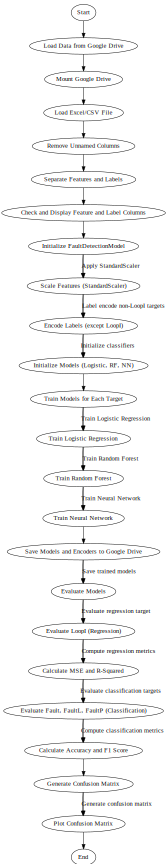

In [ ]:
from graphviz import Digraph

# Initialize the graph
dot = Digraph(comment='Detailed Fault Detection Model Pipeline')
dot.attr(rankdir='TB', size='10,12')

# Data loading nodes
dot.node('A', 'Start')
dot.node('B', 'Load Data from Google Drive')
dot.node('B1', 'Mount Google Drive')
dot.node('B2', 'Load Excel/CSV File')
dot.node('B3', 'Remove Unnamed Columns')
dot.node('B4', 'Separate Features and Labels')
dot.node('B5', 'Check and Display Feature and Label Columns')
dot.node('C', 'Initialize FaultDetectionModel')

# Initialization nodes
dot.node('C1', 'Scale Features (StandardScaler)')
dot.node('C2', 'Encode Labels (except LoopI)')
dot.node('C3', 'Initialize Models (Logistic, RF, NN)')

# Training nodes
dot.node('D', 'Train Models for Each Target')
dot.node('D1', 'Train Logistic Regression')
dot.node('D2', 'Train Random Forest')
dot.node('D3', 'Train Neural Network')
dot.node('D4', 'Save Models and Encoders to Google Drive')

# Evaluation nodes
dot.node('E', 'Evaluate Models')
dot.node('E1', 'Evaluate LoopI (Regression)')
dot.node('E2', 'Calculate MSE and R-Squared')
dot.node('E3', 'Evaluate Fault, FaultL, FaultP (Classification)')
dot.node('E4', 'Calculate Accuracy and F1 Score')
dot.node('E5', 'Generate Confusion Matrix')
dot.node('E6', 'Plot Confusion Matrix')
dot.node('F', 'End')

# Connecting the flowchart
dot.edge('A', 'B')
dot.edge('B', 'B1')
dot.edge('B1', 'B2')
dot.edge('B2', 'B3')
dot.edge('B3', 'B4')
dot.edge('B4', 'B5')
dot.edge('B5', 'C')
dot.edge('C', 'C1')
dot.edge('C1', 'C2')
dot.edge('C2', 'C3')
dot.edge('C3', 'D')

# Training connections
dot.edge('D', 'D1')
dot.edge('D1', 'D2')
dot.edge('D2', 'D3')
dot.edge('D3', 'D4')
dot.edge('D4', 'E')

# Evaluation connections
dot.edge('E', 'E1')
dot.edge('E1', 'E2')
dot.edge('E2', 'E3')
dot.edge('E3', 'E4')
dot.edge('E4', 'E5')
dot.edge('E5', 'E6')
dot.edge('E6', 'F')

# Details on nodes
dot.edge('C', 'C1', label='Apply StandardScaler')
dot.edge('C1', 'C2', label='Label encode non-LoopI targets')
dot.edge('C2', 'C3', label='Initialize classifiers')
dot.edge('D', 'D1', label='Train Logistic Regression')
dot.edge('D1', 'D2', label='Train Random Forest')
dot.edge('D2', 'D3', label='Train Neural Network')
dot.edge('D4', 'E', label='Save trained models')
dot.edge('E', 'E1', label='Evaluate regression target')
dot.edge('E1', 'E2', label='Compute regression metrics')
dot.edge('E2', 'E3', label='Evaluate classification targets')
dot.edge('E3', 'E4', label='Compute classification metrics')
dot.edge('E5', 'E6', label='Generate confusion matrix')

# Render and display the flowchart
dot.render('/content/detailed_fault_detection_pipeline_flowchart', format='png', view=True)
dot


In [ ]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from joblib import load
from google.colab import drive
from sklearn.metrics import f1_score, confusion_matrix, classification_report, mean_squared_error, r2_score

class LabeledFaultDetector:
    def __init__(self, excel_path):
        """
        Initialize the predictor with labeled Excel data

        Parameters:
        excel_path: str, path to Excel file in Google Drive
        """
        try:
            # Mount Google Drive
            drive.mount('/content/drive')

            # Load the labeled data
            self.df = pd.read_excel(excel_path)
            print(f"Loaded data with {len(self.df)} rows")

            # Load feature names and scaler
            self.feature_names = load('/content/drive/MyDrive/feature_names.joblib')
            self.scaler = load('/content/drive/MyDrive/scaler.joblib')

            # Define classification and regression targets
            self.classification_targets = ['Fault', 'FaultL', 'FaultP']
            self.regression_targets = ['LoopI']

            # Separate features and labels
            self.X = self.df[self.feature_names]
            self.y = self.df[self.classification_targets + self.regression_targets]

            # Initialize dictionaries to store models and label encoders
            self.classification_models = {target: {} for target in self.classification_targets}
            self.regression_models = {target: {} for target in self.regression_targets}
            self.label_encoders = {}

            # Load classification models and label encoders
            for target in self.classification_targets:
                try:
                    # Load models
                    self.classification_models[target]['lr'] = load(f'/content/drive/MyDrive/classification_lr_model_{target}.joblib')
                    self.classification_models[target]['rf'] = load(f'/content/drive/MyDrive/classification_rf_model_{target}.joblib')
                    self.classification_models[target]['nn'] = load(f'/content/drive/MyDrive/classification_nn_model_{target}.joblib')

                    # Load label encoder
                    self.label_encoders[target] = load(f'/content/drive/MyDrive/label_encoder_{target}.joblib')
                    print(f"Successfully loaded classification models for {target}")
                except FileNotFoundError:
                    print(f"Warning: Classification models for {target} not found. This target will be skipped.")
                    self.classification_models.pop(target)

            # Load regression models
            for target in self.regression_targets:
                try:
                    # Load models
                    self.regression_models[target]['lr'] = load(f'/content/drive/MyDrive/regression_lr_model_{target}.joblib')
                    self.regression_models[target]['rf'] = load(f'/content/drive/MyDrive/regression_rf_model_{target}.joblib')
                    self.regression_models[target]['nn'] = load(f'/content/drive/MyDrive/regression_nn_model_{target}.joblib')
                    print(f"Successfully loaded regression models for {target}")
                except FileNotFoundError:
                    print(f"Warning: Regression models for {target} not found. This target will be skipped.")
                    self.regression_models.pop(target)

            if not self.classification_models and not self.regression_models:
                raise ValueError("No models were successfully loaded.")

            print("\nPredictor initialized successfully!")

        except Exception as e:
            raise Exception(f"Error initializing predictor: {str(e)}")

    def evaluate_all_models(self):
        """Evaluate and compare all models (LR, RF, NN) on the labeled data"""
        # Scale features
        X_scaled = self.scaler.transform(self.X)

        results = {}

        # Evaluate classification models
        for target in self.classification_models.keys():
            results[target] = {}
            print(f"\nEvaluating classification models for {target}:")

            for model_type in ['lr', 'rf', 'nn']:
                y_pred = self.classification_models[target][model_type].predict(X_scaled)
                y_true = self.y[target]

                # Calculate classification metrics
                f1 = f1_score(y_true, y_pred, average='weighted')
                cm = confusion_matrix(y_true, y_pred)
                report = classification_report(y_true, y_pred, output_dict=True)

                # Store results
                results[target][model_type] = {
                    'f1_score': f1,
                    'confusion_matrix': cm,
                    'classification_report': report
                }

                # Print results
                print(f"\n{model_type.upper()} Model:")
                print(f"F1 Score: {f1:.4f}")
                print("\nClassification Report:")
                print(classification_report(y_true, y_pred))

        # Evaluate regression models
        for target in self.regression_models.keys():
            results[target] = {}
            print(f"\nEvaluating regression models for {target}:")

            for model_type in ['lr', 'rf', 'nn']:
                y_pred = self.regression_models[target][model_type].predict(X_scaled)
                y_true = self.y[target]

                # Calculate regression metrics
                mse = mean_squared_error(y_true, y_pred)
                r2 = r2_score(y_true, y_pred)

                # Store results
                results[target][model_type] = {
                    'mse': mse,
                    'r2': r2
                }

                # Print results
                print(f"\n{model_type.upper()} Model:")
                print(f"Mean Squared Error: {mse:.4f}")
                print(f"R-squared: {r2:.4f}")

        return results

    def plot_model_comparison(self, results):
        """Plot F1 scores and R-squared comparison for all models and targets"""
        # Prepare data for plotting
        plot_data = []

        # Add classification results
        for target in self.classification_models.keys():
            for model_type in results[target].keys():
                plot_data.append({
                    'Target': target,
                    'Model': model_type.upper(),
                    'Metric': 'F1 Score',
                    'Value': results[target][model_type]['f1_score']
                })

        # Add regression results
        for target in self.regression_models.keys():
            for model_type in results[target].keys():
                plot_data.append({
                    'Target': target,
                    'Model': model_type.upper(),
                    'Metric': 'R-squared',
                    'Value': results[target][model_type]['r2']
                })

        # Create grouped bar plot
        fig = px.bar(
            pd.DataFrame(plot_data),
            x='Target',
            y='Value',
            color='Model',
            barmode='group',
            facet_col='Metric',
            title='Model Performance Comparison',
            template='plotly_white'
        )

        fig.update_layout(
            height=600,
            width=1000,
            yaxis_title='Metric Value',
            xaxis_title='Target Variable'
        )

        fig.show()

    def plot_confusion_matrices(self, results, model_type='rf'):
        """Plot interactive confusion matrices for specified model type"""
        num_targets = len(self.classification_models)
        fig = make_subplots(
            rows=1, cols=num_targets,
            subplot_titles=[f"{target} - {model_type.upper()} Model"
                          for target in self.classification_models.keys()]
        )

        for idx, target in enumerate(self.classification_models.keys(), 1):
            cm = results[target][model_type]['confusion_matrix']
            classes = self.label_encoders[target].classes_

            # Create heatmap
            heatmap = go.Heatmap(
                z=cm,
                x=classes,
                y=classes,
                text=cm,
                texttemplate="%{text}",
                textfont={"size": 16},
                colorscale='Blues'
            )

            fig.add_trace(heatmap, row=1, col=idx)

            # Update layout for each subplot
            fig.update_xaxes(title_text="Predicted", row=1, col=idx)
            fig.update_yaxes(title_text="Actual", row=1, col=idx)

        fig.update_layout(
            height=500,
            width=400*num_targets,
            showlegend=False,
            title_text=f"Confusion Matrices - {model_type.upper()} Model"
        )

        fig.show()

    def plot_regression_results(self, model_type='rf'):
        """Plot actual vs predicted values for regression targets"""
        # Scale features
        X_scaled = self.scaler.transform(self.X)

        # Create subplots for each regression target
        fig = make_subplots(
            rows=1, cols=len(self.regression_models),
            subplot_titles=[f"{target} - {model_type.upper()} Model"
                          for target in self.regression_models.keys()]
        )

        for idx, target in enumerate(self.regression_models.keys(), 1):
            # Make predictions
            y_pred = self.regression_models[target][model_type].predict(X_scaled)
            y_true = self.y[target]

            # Add scatter plot
            fig.add_trace(
                go.Scatter(
                    x=y_true,
                    y=y_pred,
                    mode='markers',
                    marker=dict(color='blue', size=8),
                    name='Data Points'
                ),
                row=1, col=idx
            )

            # Add 45-degree line
            fig.add_trace(
                go.Scatter(
                    x=np.linspace(min(y_true), max(y_true), 100),
                    y=np.linspace(min(y_true), max(y_true), 100),
                    mode='lines',
                    line=dict(color='red', width=2),
                    name='45-degree Line'
                ),
                row=1, col=idx
            )

            # Update axes labels
            fig.update_xaxes(title_text="Actual", row=1, col=idx)
            fig.update_yaxes(title_text="Predicted", row=1, col=idx)

        fig.update_layout(
            height=500,
            width=800*len(self.regression_models),
            title_text=f"Actual vs Predicted - {model_type.upper()} Model",
            showlegend=False
        )

        fig.show()

# Example usage
if __name__ == "__main__":
    try:
        # Initialize predictor with your Excel file
        excel_path = '/content/drive/MyDrive/Book4.xlsx'  # Update with your file path
        detector = LabeledFaultDetector(excel_path)

        # Evaluate all models
        results = detector.evaluate_all_models()

        # Plot comparisons
        detector.plot_model_comparison(results)

        # Plot confusion matrices for RF model (you can change to 'lr' or 'nn')
        detector.plot_confusion_matrices(results, model_type='rf')

        # Plot regression results for RF model
        detector.plot_regression_results(model_type='rf')

    except Exception as e:
        print(f"Error in evaluation pipeline: {str(e)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded data with 109 rows
Successfully loaded classification models for Fault
Successfully loaded classification models for FaultL
Successfully loaded classification models for FaultP
Successfully loaded regression models for LoopI

Predictor initialized successfully!

Evaluating classification models for Fault:

LR Model:
F1 Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        95

    accuracy                           1.00       109
   macro avg       1.00      1.00      1.00       109
weighted avg       1.00      1.00      1.00       109


RF Model:
F1 Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1     

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00        95

    accuracy                           0.13       109
   macro avg       0.33      0.33      0.33       109
weighted avg       0.13      0.13      0.13       109


RF Model:
F1 Score: 0.1284

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00        95

    accuracy                           0.13       109
   macro avg       0.33      0.33      0.33       109
weighted avg       0.13      0.13      0.13       109


NN Model:
F1 Score: 0.1284

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.00  

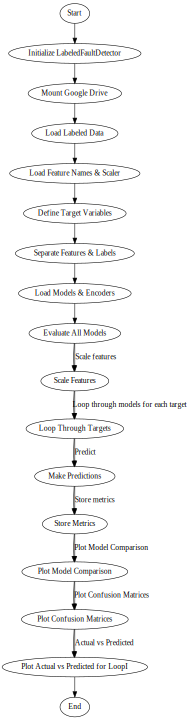

In [ ]:
from graphviz import Digraph

# Initialize the graph
dot = Digraph(comment='Fault Detection Model Pipeline')
dot.attr(rankdir='TB', size='8,10')

# Main nodes in the flowchart
dot.node('A', 'Start')
dot.node('B', 'Initialize LabeledFaultDetector')
dot.node('C1', 'Mount Google Drive')
dot.node('C2', 'Load Labeled Data')
dot.node('C3', 'Load Feature Names & Scaler')
dot.node('C4', 'Define Target Variables')
dot.node('C5', 'Separate Features & Labels')
dot.node('C6', 'Load Models & Encoders')
dot.node('D', 'Evaluate All Models')
dot.node('D1', 'Scale Features')
dot.node('D2', 'Loop Through Targets')
dot.node('D3', 'Make Predictions')
dot.node('D4', 'Store Metrics')
dot.node('E', 'Plot Model Comparison')
dot.node('F', 'Plot Confusion Matrices')
dot.node('G', 'Plot Actual vs Predicted for LoopI')
dot.node('H', 'End')

# Define edges for main steps
dot.edge('A', 'B')
dot.edge('B', 'C1')
dot.edge('C1', 'C2')
dot.edge('C2', 'C3')
dot.edge('C3', 'C4')
dot.edge('C4', 'C5')
dot.edge('C5', 'C6')
dot.edge('C6', 'D')
dot.edge('D', 'D1')
dot.edge('D1', 'D2')
dot.edge('D2', 'D3')
dot.edge('D3', 'D4')
dot.edge('D4', 'E')
dot.edge('E', 'F')
dot.edge('F', 'G')
dot.edge('G', 'H')

# Sub-step nodes for detailed evaluation process
dot.edge('D', 'D1', label='Scale features')
dot.edge('D1', 'D2', label='Loop through models for each target')
dot.edge('D2', 'D3', label='Predict')
dot.edge('D3', 'D4', label='Store metrics')

# Visualization steps
dot.edge('D4', 'E', label='Plot Model Comparison')
dot.edge('E', 'F', label='Plot Confusion Matrices')
dot.edge('F', 'G', label='Actual vs Predicted')

# Render and display the flowchart
dot.render('/content/fault_detection_pipeline_flowchart', format='png', view=True)
dot
